<a href="https://colab.research.google.com/github/Mytros/DS_ML_homework/blob/main/HW_3_1_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97_DKoval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/DS_ML/marketing_campaign.csv", sep="\t")

# Show dataset shape (rows, columns)
print("Dataset shape:", df.shape)

# Display column data types and non-null counts
df.info()

# Check for missing values in each column
print("\nMissing values per column:")
print(df.isna().sum())
print("\n")
df.head(20)


Dataset shape: (2240, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurc

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,20,1,0,0,0,0,0,3,11,0


**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [5]:
# Fill missing values in Income with the median
df['Income'] = df['Income'].fillna(df['Income'].median())

# Verify that no missing values remain in the dataset
print("Missing values per column after filling:")
print(df.isna().sum())


Missing values per column after filling:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


Відповідь:

Чому я використав median?

Доходи (Income) мають сильно скошений розподіл (є клієнти з дуже високим доходом).

Якщо використати середнє (mean), воно буде зміщене у бік цих великих значень і не відображатиме типового клієнта.

Медіана є більш стійкою до викидів, тому вона краще підходить, щоб типове значення заповнювало пропуски.


**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [7]:
# Drop non-informative
cols_to_drop = [c for c in ['ID', 'Z_CostContact', 'Z_Revenue'] if c in df.columns]
df = df.drop(columns=cols_to_drop)

# Ensure binary columns are integers (0/1)
binary_cols = [c for c in df.columns if c.startswith('AcceptedCmp') or c in ['Complain', 'Response']]
for c in binary_cols:
    if c in df.columns:
        df[c] = df[c].astype(int)

# Convert tenure to months for more interpretable scale
if 'Customer_For' in df.columns:
    df['Customer_For_Months'] = (df['Customer_For'] / 30.44).round(1)
    # Keep both or drop the original; for clustering, keeping one is cleaner:
    df = df.drop(columns=['Customer_For'])

print("Current columns:", df.columns.tolist())
print("\nDtypes summary:\n", df.dtypes.value_counts())
print("\nAny missing values?", df.isna().any().any(), "\n")

df.head()


Current columns: ['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']

Dtypes summary:
 int64      22
object      3
float64     1
Name: count, dtype: int64

Any missing values? False 



,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,10,4,7,0,0,0,0,0,0,1
1,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,1,2,5,0,0,0,0,0,0,0
2,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,2,10,4,0,0,0,0,0,0,0
3,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,0,4,6,0,0,0,0,0,0,0
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,3,6,5,0,0,0,0,0,0,0


- Викидаємо ID, бо це просто ідентифікатор i не несе користі.

- Z_CostContact/Z_Revenue у цьому датасеті константи — для відстаней у кластеризації вони не додають інформації й лише впливають на масштаб.

- Переводимо бінарні до int, щоб уникнути неочікуваної обробки типів.

- Customer_For у місяцях інколи інтерпретують простіше; для алгоритмів це все одно число, але шкала стає ближчою до звичних величин.

### Answer:

- ID: removed, since it is only an identifier and does not describe customer behavior.  
- Z_CostContact / Z_Revenue: dropped, because they are constant and do not help to distinguish customers.  
- Binary columns (0/1): kept as integers so clustering algorithms can treat them correctly.  
- Customer_For: converted from days to months, because months are easier to interpret than raw days.


**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Select only numeric columns
X = df.select_dtypes(include=['int64', 'float64'])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)

# Compute silhouette score
sil_score = silhouette_score(X_scaled, labels)
print("Silhouette score for 3 clusters:", sil_score)

# cluster sizes

unique, counts = np.unique(labels, return_counts=True)
print("Cluster sizes:", dict(zip(unique, counts)))


Silhouette score for 3 clusters: 0.23831442223340196
Cluster sizes: {np.int32(0): np.int64(1239), np.int32(1): np.int64(801), np.int32(2): np.int64(200)}


Silhouette score for 3 clusters: 0.23831442223340196
Cluster sizes: {np.int32(0): np.int64(1239), np.int32(1): np.int64(801), np.int32(2): np.int64(200)}
For n_clusters = 2, average silhouette score = 0.2667


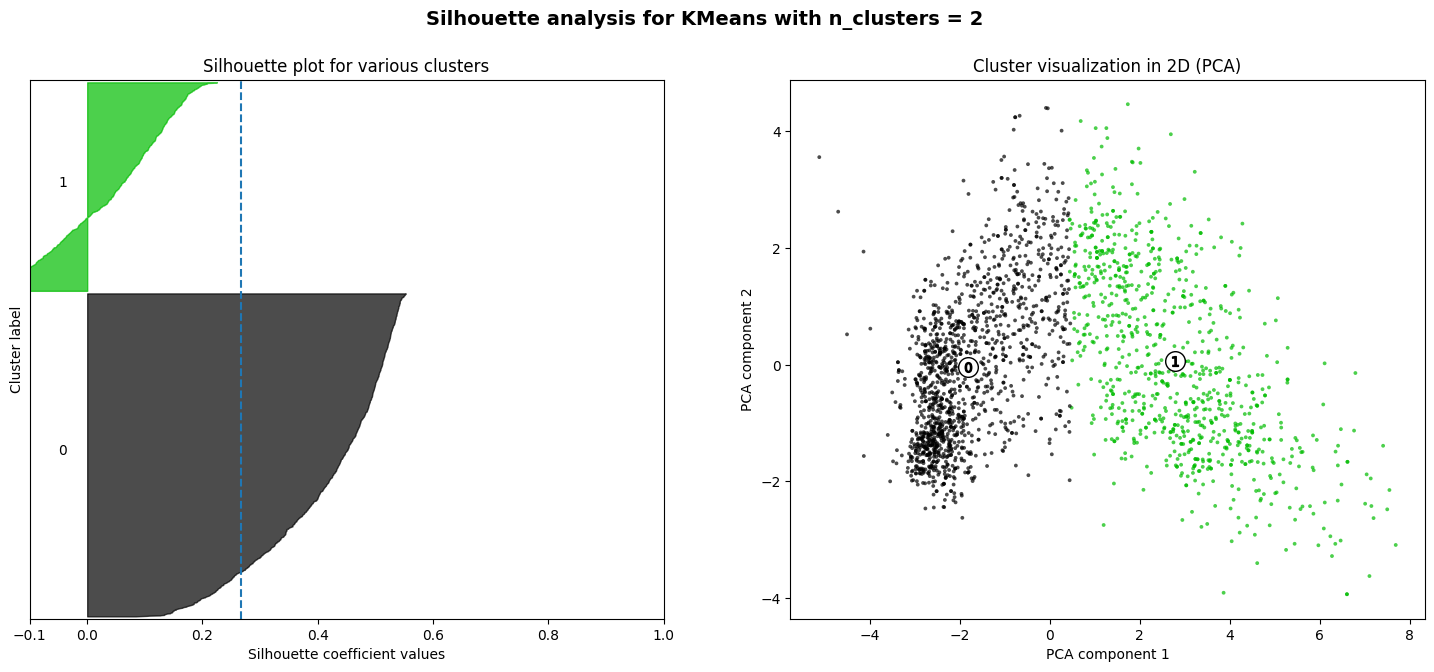

For n_clusters = 3, average silhouette score = 0.2383


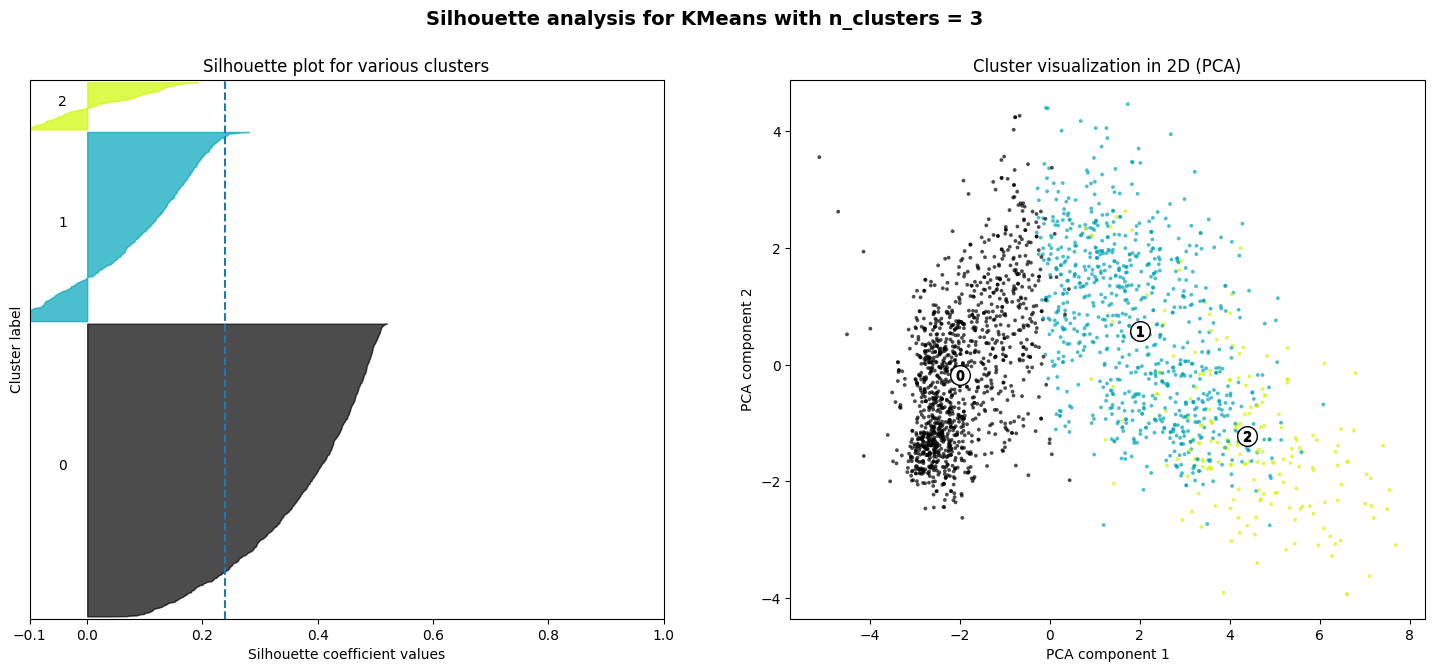

For n_clusters = 4, average silhouette score = 0.1921


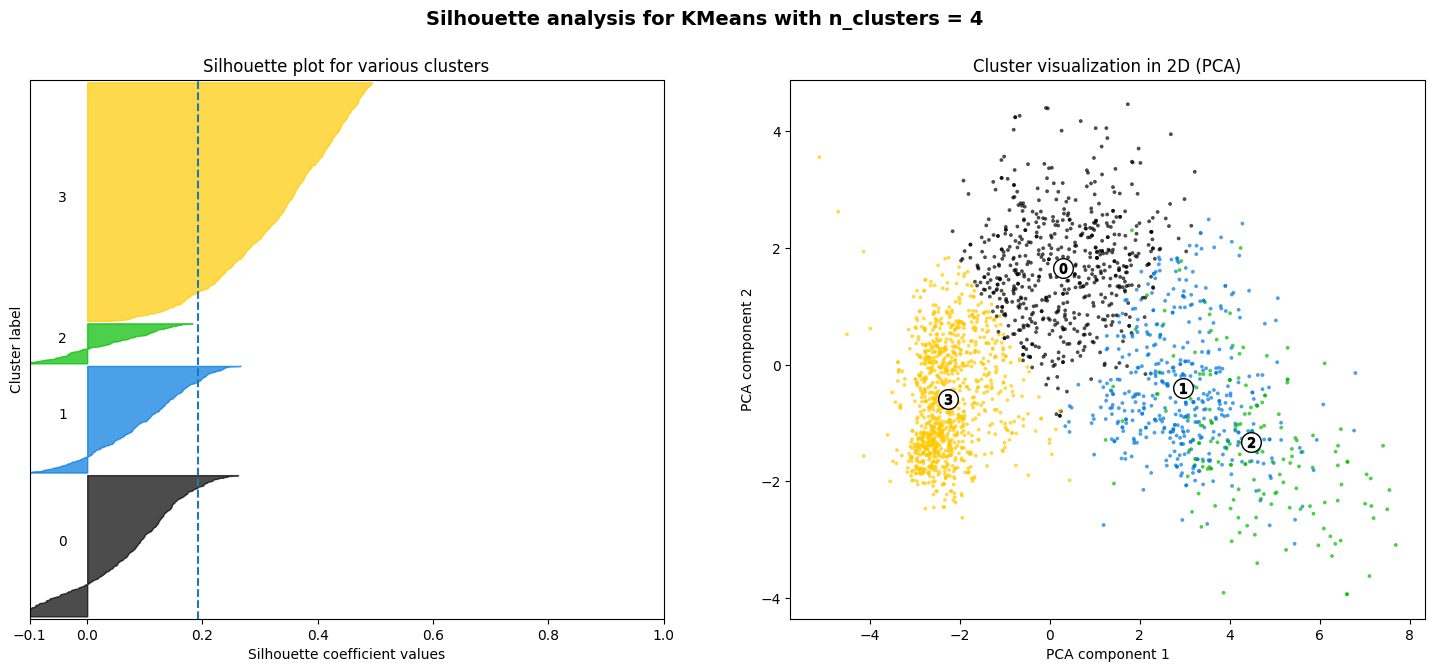

For n_clusters = 5, average silhouette score = 0.1831


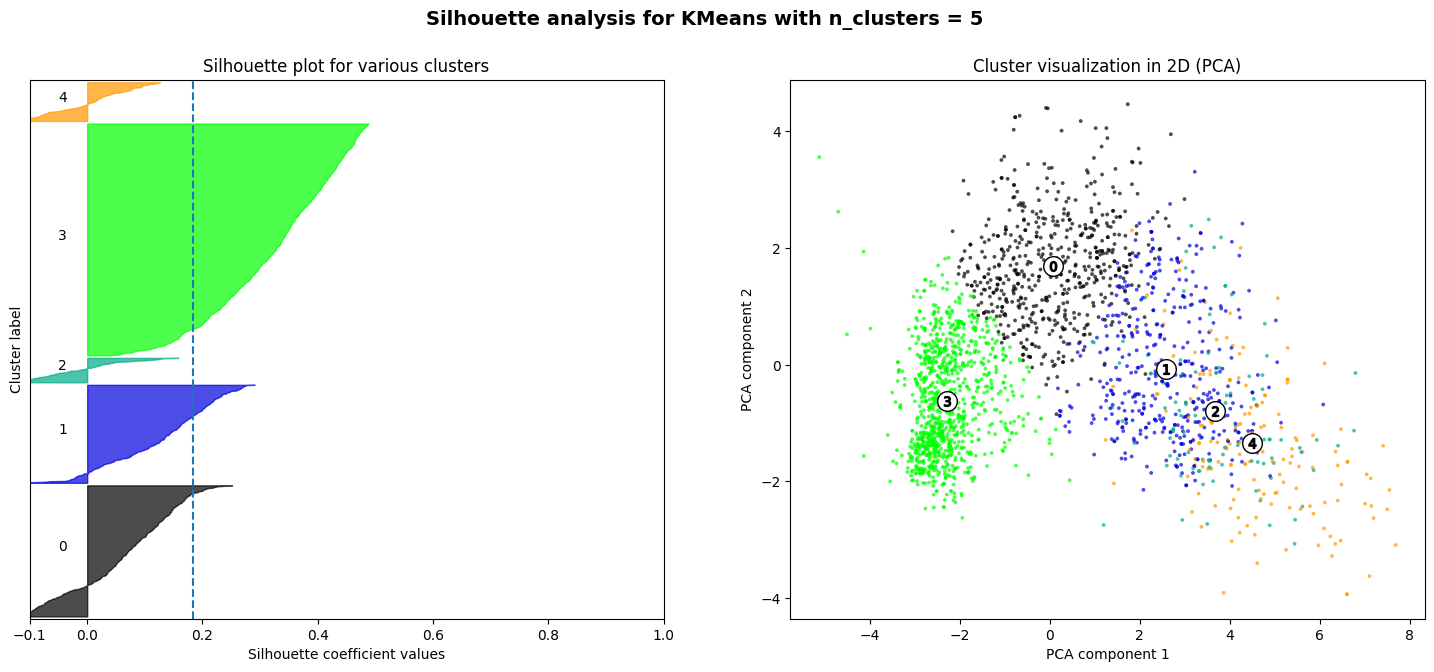

For n_clusters = 6, average silhouette score = 0.1965


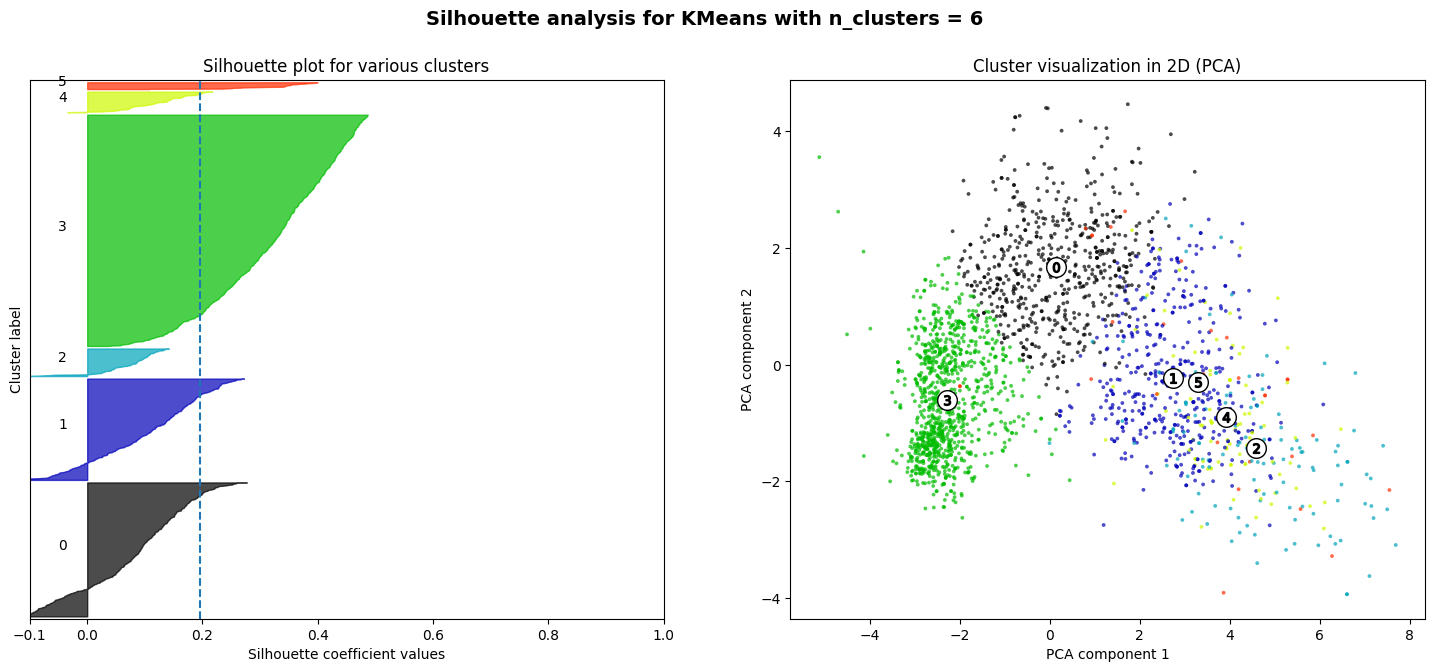

In [9]:
#v2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Select only numeric columns
X = df.select_dtypes(include=['int64', 'float64'])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Single run for K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)
sil_score_3 = silhouette_score(X_scaled, labels)
print("Silhouette score for 3 clusters:", sil_score_3)

unique, counts = np.unique(labels, return_counts=True)
print("Cluster sizes:", dict(zip(unique, counts)))

# Silhouette analysis for several values of K
range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, X_scaled.shape[0] + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    cluster_labels = clusterer.fit_predict(X_scaled)

    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print(f"For n_clusters = {n_clusters}, average silhouette score = {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title("Silhouette plot for various clusters")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.axvline(x=silhouette_avg, linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2D visualization using PCA
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X_pca[:, 0], X_pca[:, 1], marker=".", s=30, lw=0, alpha=0.7,
                c=colors, edgecolor="k")

    # Project cluster centers to PCA space
    centers = clusterer.cluster_centers_
    centers_pca = pca.transform(centers)
    ax2.scatter(centers_pca[:, 0], centers_pca[:, 1], marker="o", c="white",
                alpha=1, s=200, edgecolor="k")

    for i, c in enumerate(centers_pca):
        ax2.scatter(c[0], c[1], marker=f"${i}$", alpha=1, s=50, edgecolor="k")

    ax2.set_title("Cluster visualization in 2D (PCA)")
    ax2.set_xlabel("PCA component 1")
    ax2.set_ylabel("PCA component 2")

    plt.suptitle(f"Silhouette analysis for KMeans with n_clusters = {n_clusters}",
                 fontsize=14, fontweight="bold")

    plt.show()


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [10]:
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select numeric features and scale
X = df.select_dtypes(include=['int64', 'float64'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit KMeans with 3 clusters (from task 4)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)

# Add cluster labels back to original dataframe
df['Cluster'] = labels

# Choose features for visualization
features = ['Income', 'NumStorePurchases', 'NumWebPurchases']

fig = px.scatter_3d(
    df,
    x='Income',
    y='NumStorePurchases',
    z='NumWebPurchases',
    color=df['Cluster'].astype(str),  # make clusters categorical
    symbol='Cluster',
    opacity=0.7,
    title="3D visualization of customer clusters"
)

fig.update_traces(marker=dict(size=5))  # smaller markers for clarity
fig.show()



### Висновки щодо візуалізації кластерів (KMeans, k=3)

1. Червоний кластер (Cluster 0):
   - Клієнти з низькими доходами.  
   - Мають небагато покупок як онлайн, так і в магазині.  
   - Це базові клієнти з мінімальною взаємодією.  

2. Зелений кластер (Cluster 2):  
   - Клієнти із середнім рівнем доходів.  
   - Здійснюють більше покупок (і онлайн, і офлайн).  
   - Активні покупці середнього сегменту.  

3. Синій кластер (Cluster 1):
   - Клієнти з дуже високим доходом та кількістю онлайн-покупок.  
   - Ймовірно, це преміальний сегмент або навіть викиди.  

### Загальні спостереження
- Поділ має сенс: видно два основних сегменти (малобюджетні неактивні та середньобюджетні активні).  
- Третій кластер формується за рахунок клієнтів з високими доходами.  



**Завдання 6**. Масштабуйте дані і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Select numeric features
X = df.drop(columns=['Cluster'], errors='ignore')  # drop old cluster labels if present
X = X.select_dtypes(include=['int64', 'float64'])

# Without scaling
kmeans_no_scaling = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels_no_scaling = kmeans_no_scaling.fit_predict(X)
sil_no_scaling = silhouette_score(X, labels_no_scaling)
print("Silhouette score without scaling:", sil_no_scaling)

# With scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels_scaled = kmeans_scaled.fit_predict(X_scaled)
sil_scaled = silhouette_score(X_scaled, labels_scaled)
print("Silhouette score with scaling:", sil_scaled)


Silhouette score without scaling: 0.5383704757775578
Silhouette score with scaling: 0.23831442223340196


Висновок:

Без масштабування - кластери чіткі, але фактично вони базуються майже тільки на доході. Це може бути занадто спрощеною інтепретацією (групи: бідні, середні, багаті).

З масштабуванням - ураховано більше поведінкових характеристик, але кластери стали менш відокремленими за метрикою. Зате вони можуть мати більше бізнес-сенсу (наприклад, відрізняти активних середньодоходних клієнтів від пасивних високодоходних).

Тобто:

Якщо завдання - просто поділити за доходом, то масштабування шкодить.

Якщо знайти складніші портрети клієнтів, масштабування правильне, навіть якщо силует нижчий.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [15]:
# Copy df
df_clean = df.copy()

# Handle outliers in Income with IQR method
Q1 = df_clean['Income'].quantile(0.25)
Q3 = df_clean['Income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Income lower bound:", lower_bound)
print("Income upper bound:", upper_bound)

# Filter dataset
df_clean = df_clean[(df_clean['Income'] >= lower_bound) & (df_clean['Income'] <= upper_bound)]

print("Original shape:", df.shape)
print("After removing outliers:", df_clean.shape)


Income lower bound: -13587.75
Income upper bound: 117416.25
Original shape: (2240, 27)
After removing outliers: (2232, 27)


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Take cleaned dataset (without outliers)
X_clean = df_clean.select_dtypes(include=['int64', 'float64'])

# --- Without scaling ---
kmeans_no_scaling = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels_no_scaling = kmeans_no_scaling.fit_predict(X_clean)
sil_no_scaling = silhouette_score(X_clean, labels_no_scaling)
print("Silhouette score without scaling (after outlier removal):", sil_no_scaling)

# --- With scaling ---
scaler = StandardScaler()
X_clean_scaled = scaler.fit_transform(X_clean)

kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels_scaled = kmeans_scaled.fit_predict(X_clean_scaled)
sil_scaled = silhouette_score(X_clean_scaled, labels_scaled)
print("Silhouette score with scaling (after outlier removal):", sil_scaled)


Silhouette score without scaling (after outlier removal): 0.5522575613883447
Silhouette score with scaling (after outlier removal): 0.1958505264697523


### Порівняння коефіцієнта силуету

| Датасет                   | Без масштабування | З масштабуванням |
|---------------------------|------------------:|-----------------:|
| До видалення викидів      | 0.538             | 0.238            |
| Після видалення викидів   | 0.552             | 0.196            |

**Висновок:**
- Видалення викидів трохи покращило кластеризацію без масштабування (0.538 -> 0.552).  
- При масштабуванні значення силуету зменшилися після видалення викидів (0.238 -> 0.196).  
- Без масштабування кластери формуються головним чином за рахунок **доходу**, що дає чіткіший поділ.  
- З масштабуванням на кластеризацію впливає більше ознак (покупки, кампанії тощо), але кластери стають менш відокремленими.  



**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

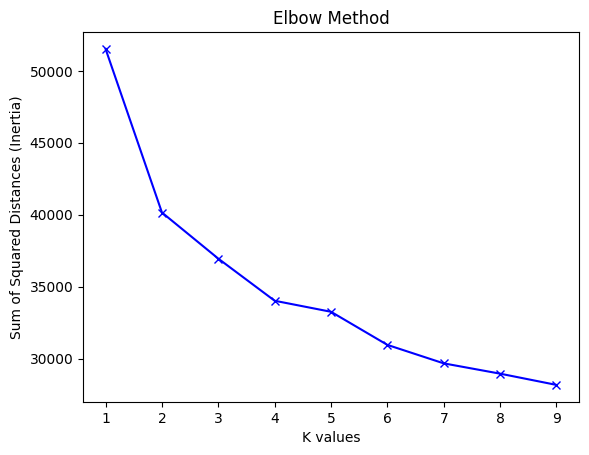

Silhouette score for K=3: 0.23831442223340196


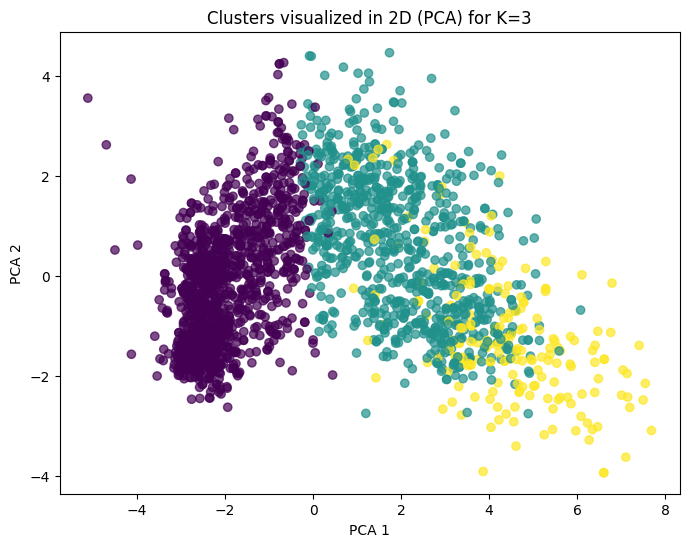

In [21]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Scale numeric features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
K = range(1, 10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_scaled)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.title('Elbow Method')
plt.show()

# Train KMeans with hardcode K = 3, 4
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, n_init='auto', random_state=42)
labels = kmeans.fit_predict(X_scaled)

#  Silhouette score
sil_score = silhouette_score(X_scaled, labels)
print(f"Silhouette score for K={optimal_k}:", sil_score)

#  2D Visualization via PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', alpha=0.7)
plt.title(f"Clusters visualized in 2D (PCA) for K={optimal_k}")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


Silhouette score for K=3: 0.2383


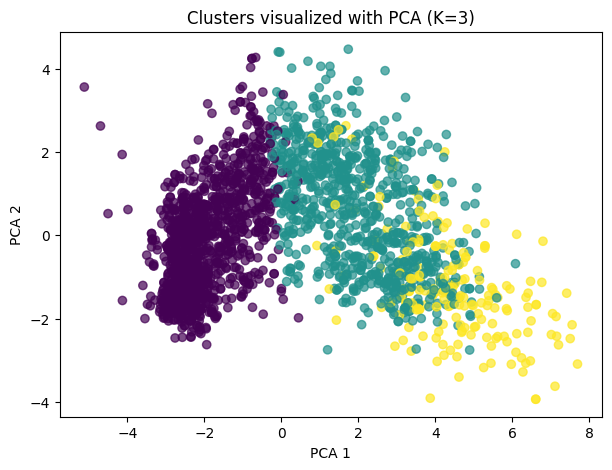

Silhouette score for K=4: 0.1921


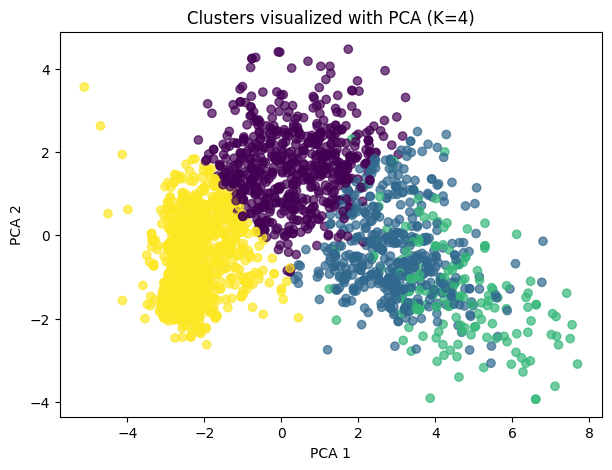

In [22]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Take numeric features
X_num = df.select_dtypes(include=['int64', 'float64'])

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# Try K=3 and K=4
for k in [3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    print(f"Silhouette score for K={k}: {sil:.4f}")

    # PCA for visualization
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(7,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', alpha=0.7)
    plt.title(f"Clusters visualized with PCA (K={k})")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()


Silhouette score for K=2: 0.2667
Silhouette score for K=3: 0.2383
Silhouette score for K=4: 0.1921
Silhouette score for K=5: 0.1831
Silhouette score for K=6: 0.1965
Silhouette score for K=7: 0.1298
Silhouette score for K=8: 0.1097
Silhouette score for K=9: 0.1124
Silhouette score for K=10: 0.1158


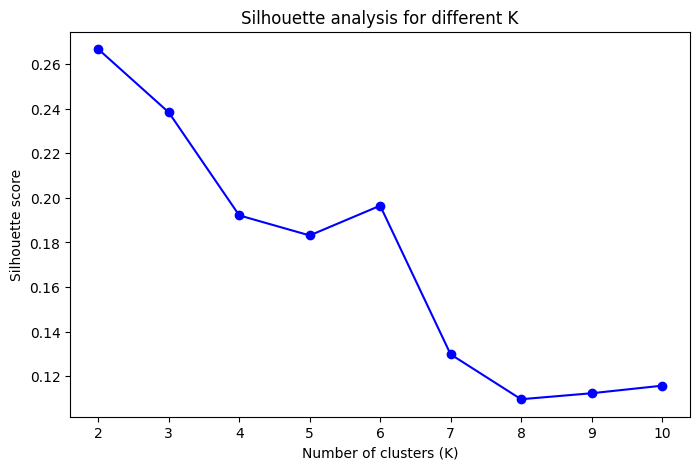

In [23]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Numeric features
X_num = df.select_dtypes(include=['int64', 'float64'])

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

silhouette_scores = []

K = range(2, 11)  # from 2 to 10
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"Silhouette score for K={k}: {sil:.4f}")

# Plot silhouette scores
plt.figure(figsize=(8,5))
plt.plot(K, silhouette_scores, 'bo-')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.title("Silhouette analysis for different K")
plt.show()


Silhouette score for K=2 (no scaling): 0.5944
Silhouette score for K=3 (no scaling): 0.5384
Silhouette score for K=4 (no scaling): 0.5443
Silhouette score for K=5 (no scaling): 0.5249
Silhouette score for K=6 (no scaling): 0.5278
Silhouette score for K=7 (no scaling): 0.5418
Silhouette score for K=8 (no scaling): 0.5184
Silhouette score for K=9 (no scaling): 0.5174
Silhouette score for K=10 (no scaling): 0.5216


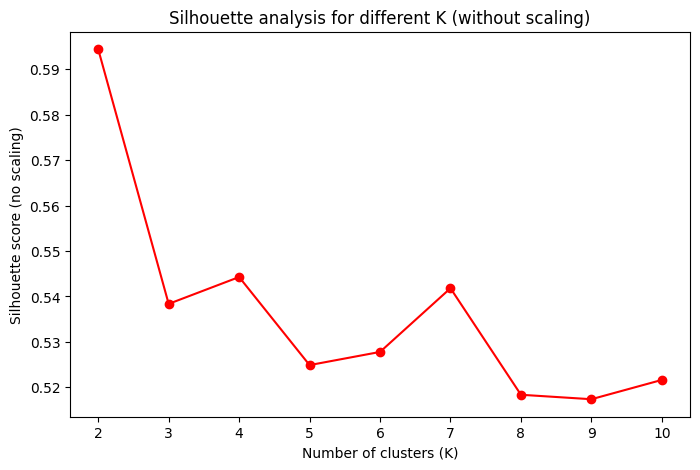

In [ ]:
# not scaled
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Numeric features (without scaling)
X_num = df.select_dtypes(include=['int64', 'float64'])

silhouette_scores_raw = []

K = range(2, 11)  # from 2 to 10
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_num)
    sil = silhouette_score(X_num, labels)
    silhouette_scores_raw.append(sil)
    print(f"Silhouette score for K={k} (no scaling): {sil:.4f}")

# Plot silhouette scores
plt.figure(figsize=(8,5))
plt.plot(K, silhouette_scores_raw, 'ro-')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score (no scaling)")
plt.title("Silhouette analysis for different K (without scaling)")
plt.show()


**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [24]:
#  Prepare raw (unscaled) numeric data after outlier removal
import numpy as np
import pandas as pd

# Use df_clean if it exists (after outlier handling); otherwise fall back to df
data_src = df_clean if 'df_clean' in globals() else df

# Keep only numeric features and drop any pre-existing cluster labels
X_raw = data_src.select_dtypes(include=['int64', 'float64']).copy()
X_raw = X_raw.drop(columns=[c for c in X_raw.columns if c.lower() == 'cluster'], errors='ignore')

print("Shape used for hierarchical clustering:", X_raw.shape)


Shape used for hierarchical clustering: (2232, 23)


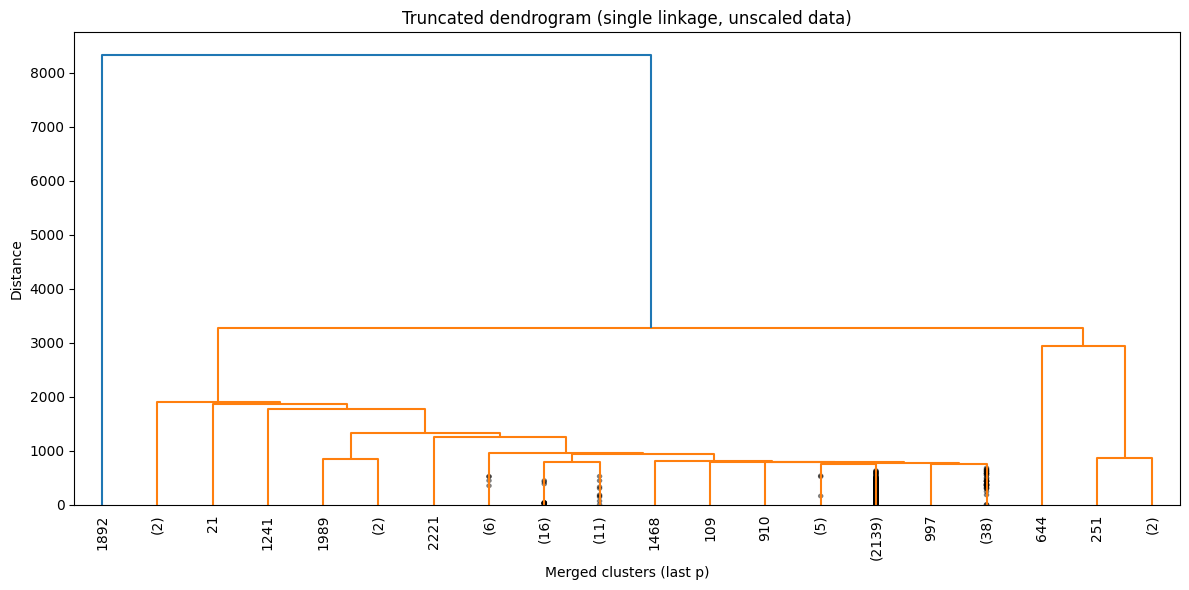

In [25]:
#  Hierarchical clustering (single linkage) on Unscaled data
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# Compute linkage matrix with single linkage (Euclidean distance)
Z = linkage(X_raw, method='single', metric='euclidean')

# Plot truncated dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=20,                    # show only the last p merged clusters
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True,
)
plt.title("Truncated dendrogram (single linkage, unscaled data)")
plt.xlabel("Merged clusters (last p)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


Silhouette score (single linkage, unscaled) for k=2: 0.5574


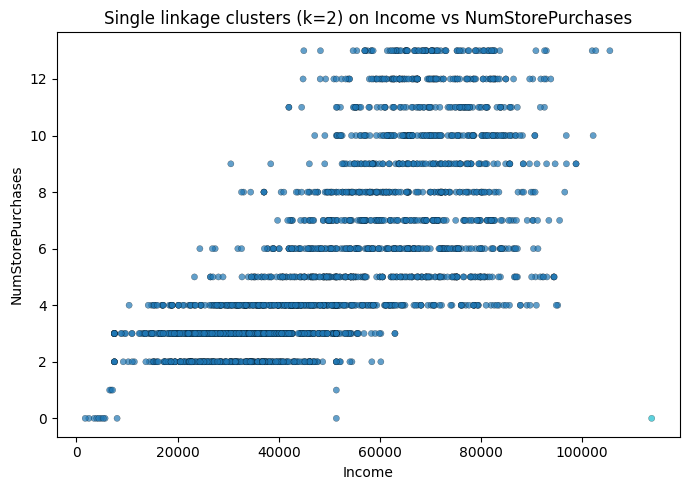

Silhouette score (single linkage, unscaled) for k=3: 0.4506


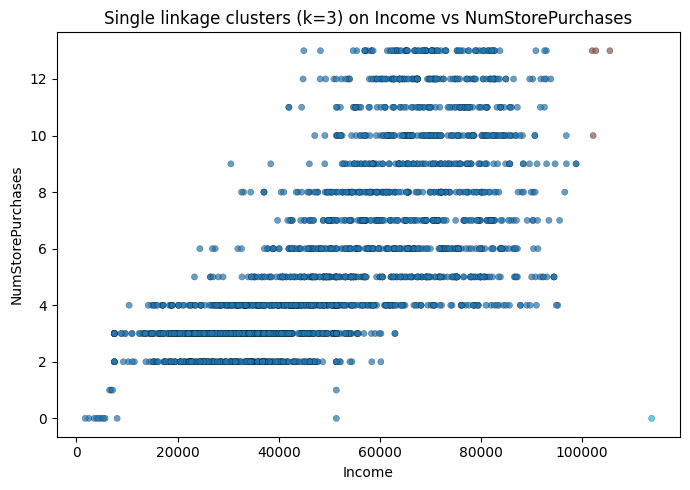

In [26]:
# Flat clustering for k=2 and k=3 using fcluster
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

results = {}
for k in [2, 3]:
    # form flat clusters by specifying the desired number of clusters
    labels_k = fcluster(Z, t=k, criterion='maxclust')
    results[k] = labels_k

    # Silhouette on the same raw (unscaled) space
    sil_k = silhouette_score(X_raw.values, labels_k)
    print(f"Silhouette score (single linkage, unscaled) for k={k}: {sil_k:.4f}")

    #  Visualize clusters in a meaningful 2D projection
    # Option A: business-meaningful axes
    x_axis, y_axis = 'Income', 'NumStorePurchases'
    has_axes = (x_axis in X_raw.columns) and (y_axis in X_raw.columns)

    if has_axes:
        plt.figure(figsize=(7,5))
        plt.scatter(X_raw[x_axis], X_raw[y_axis], c=labels_k, cmap='tab10', s=20, alpha=0.7, edgecolors='k', linewidths=0.2)
        plt.title(f"Single linkage clusters (k={k}) on {x_axis} vs {y_axis}")
        plt.xlabel(x_axis); plt.ylabel(y_axis)
        plt.tight_layout()
        plt.show()
    else:
        # Option B: PCA to 2D if selected axes are missing
        pca = PCA(n_components=2, random_state=42)
        X_pca = pca.fit_transform(X_raw.values)
        plt.figure(figsize=(7,5))
        plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_k, cmap='tab10', s=20, alpha=0.7, edgecolors='k', linewidths=0.2)
        plt.title(f"Single linkage clusters (k={k}) visualized with PCA")
        plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
        plt.tight_layout()
        plt.show()


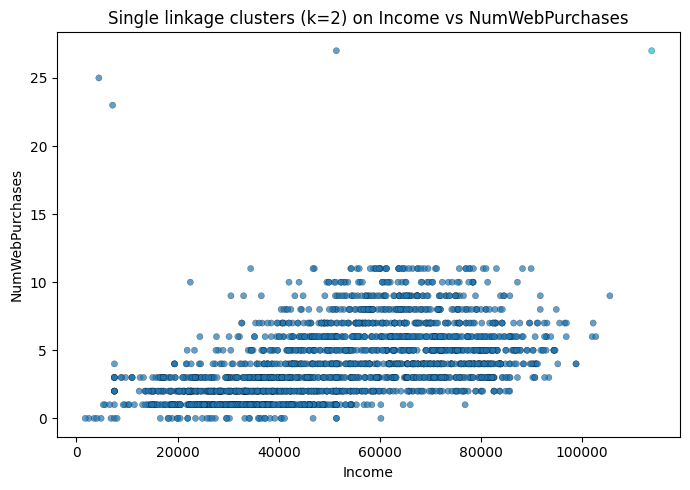

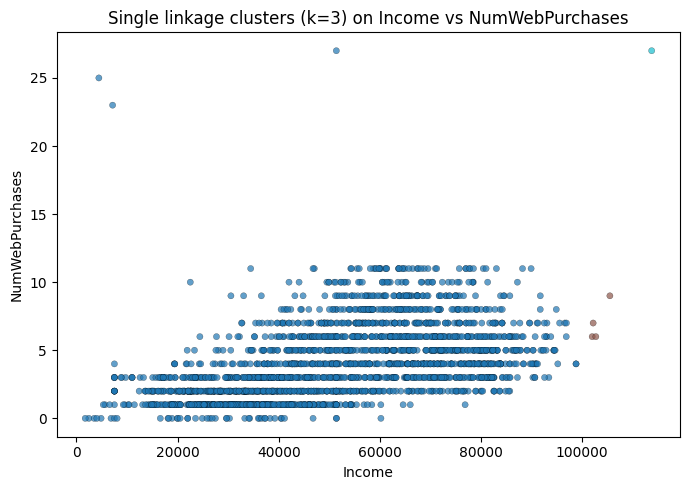

In [27]:
# Another 2D view to double-check separation
# Income vs NumWebPurchases
if 'Income' in X_raw.columns and 'NumWebPurchases' in X_raw.columns:
    for k, labels_k in results.items():
        plt.figure(figsize=(7,5))
        plt.scatter(X_raw['Income'], X_raw['NumWebPurchases'],
                    c=labels_k, cmap='tab10', s=20, alpha=0.7, edgecolors='k', linewidths=0.2)
        plt.title(f"Single linkage clusters (k={k}) on Income vs NumWebPurchases")
        plt.xlabel("Income"); plt.ylabel("NumWebPurchases")
        plt.tight_layout()
        plt.show()


# Висновки:

### Дендрограма (single linkage, unscaled):
- Має довгі “ланцюги” (характерно для single linkage).
- Є кілька великих об’єднань, які відбуваються на значній відстані -> це натякає на існування 2–3 великих груп.

### Кластеризація на 2 кластери:
- Silhouette ≈ 0.56 -> відносно непоганий результат.
- Фактично модель відділила одну велику масу клієнтів від невеликої групи.
- Це простий поділ, але він виглядає дещо “грубим” (великі класи, мало деталей).

### Кластеризація на 3 кластери:
- Silhouette ≈ 0.45 -> нижчий показник, кластери менш відокремлені.
- Один із кластерів виділяє лише невеликий сегмент клієнтів (ймовірно, з високим доходом чи великою кількістю покупок).
- Виходить більш деталізовано, але якість гірша.

### Загальні спостереження:
- Single linkage показав тенденцію до “ланцюжків” -> кластери не дуже компактні.
- Поділ на 2 кластери формально виглядає краще за силуетом, але бізнес-сенс слабкий: це просто “всі клієнти” + “кілька відхилень”.
- Поділ на 3 кластери трохи інформативніший, бо виділяє групу клієнтів із особливими характеристиками, але якість кластерів нижча.

## Підсумок:
- Чи вдала кластеризація?
Як на мене - ні: single linkage у цьому датасеті не дав виразних бізнес-сегментів.
- Single linkage тут варто розглядати радше як демонстрацію методу й його обмежень.
- Можливо, треба спробувати інші методи (KMeans, Ward linkage), які формують компактні й збалансовані групи.


**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте метрику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

Silhouette score (DBSCAN, without noise): 0.2548


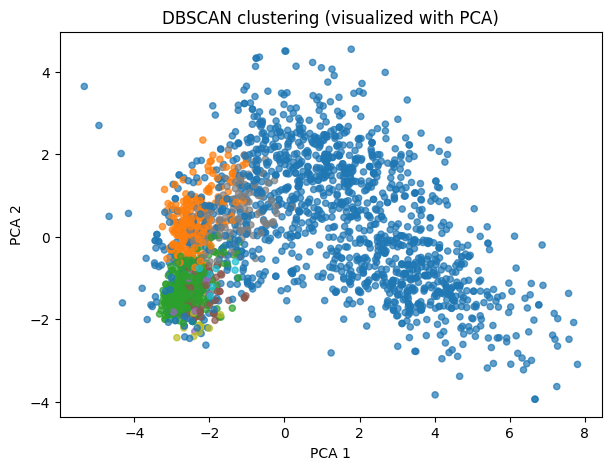

In [28]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Scale the data
X_num = df_clean.select_dtypes(include=['int64', 'float64'])  # clean data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# Run DBSCAN
db = DBSCAN(eps=1.5, min_samples=10)
labels = db.fit_predict(X_scaled)

# Silhouette score
# DBSCAN - -1 noise
mask = labels != -1
if len(set(labels[mask])) > 1:  # silhouette if ≥2 clusters
    sil = silhouette_score(X_scaled[mask], labels[mask])
    print(f"Silhouette score (DBSCAN, without noise): {sil:.4f}")
else:
    print("Not enough for clusters silhouette")

# Visualization with PCA (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10', s=20, alpha=0.7)
plt.title("DBSCAN clustering (visualized with PCA)")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.show()


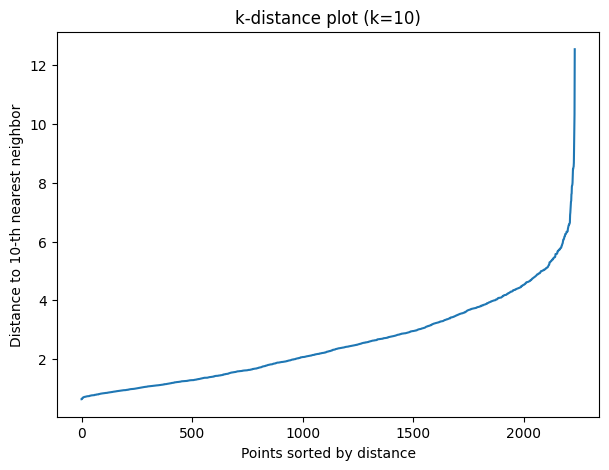

In [29]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# k = min_samples
k = 10
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# distance to 10-th neighbor
distances = np.sort(distances[:, k-1])

plt.figure(figsize=(7,5))
plt.plot(distances)
plt.title(f"k-distance plot (k={k})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {k}-th nearest neighbor")
plt.show()


Silhouette score (DBSCAN, eps=3.5, min_samples=10): 0.1693


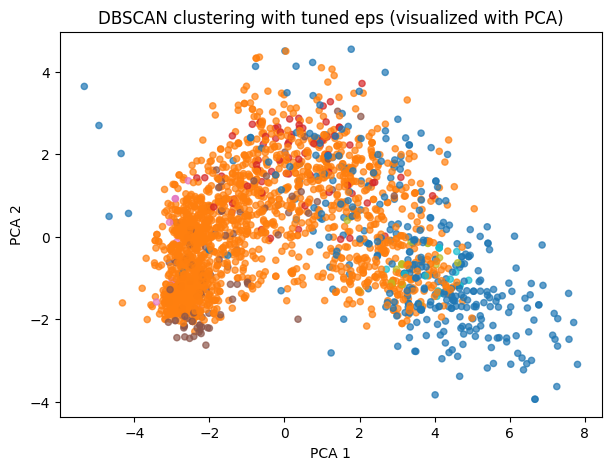

In [30]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# DBSCAN with tuned eps
db = DBSCAN(eps=3.5, min_samples=10)
labels = db.fit_predict(X_scaled)

# Silhouette (exclude noise)
mask = labels != -1
if len(set(labels[mask])) > 1:
    sil = silhouette_score(X_scaled[mask], labels[mask])
    print(f"Silhouette score (DBSCAN, eps=3.5, min_samples=10): {sil:.4f}")
else:
    print("DBSCAN produced less than 2 clusters")

# PCA visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10', s=20, alpha=0.7)
plt.title("DBSCAN clustering with tuned eps (visualized with PCA)")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.show()


### Висновки (DBSCAN)

- Метод DBSCAN дозволяє автоматично виявляти кількість кластерів та виділяти шумові точки.
- У нашому випадку він виділив кілька кластерів, але Silhouette вийшов низьким (≈0.17), що свідчить про слабку відокремленість груп.
- Візуалізація з PCA показує, що DBSCAN скоріше поділив масив клієнтів доволі довільно, без чітких бізнес-сегментів.
- Це може підтверджувати, що для маркетингових даних із багатьма перехрещеними ознаками (щільність) краще працюють інші методи.
- DBSCAN тут радше продемонстрував свої обмеження: він підходить для завдань з "острівними" даними і наявністю шуму, але не для щільних даних із плавними переходами між групами.


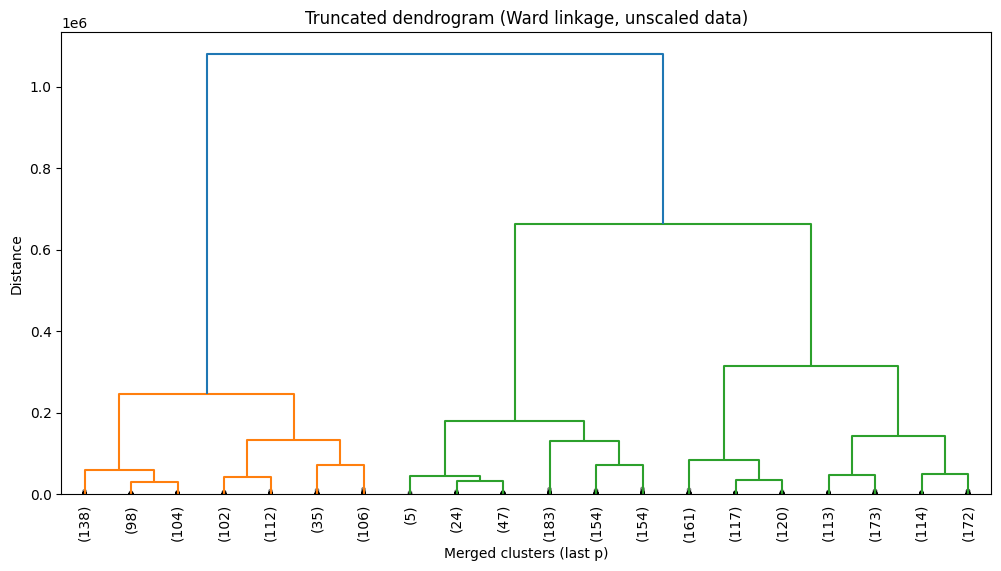

Silhouette score (Ward linkage, unscaled, k=3): 0.5353


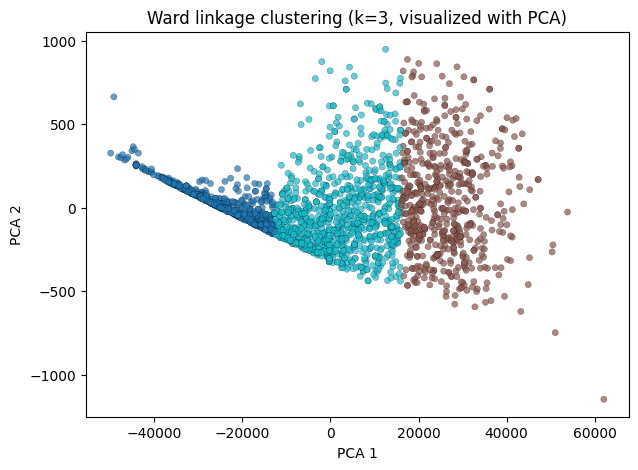

In [32]:
# Ward linkage
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# raw data
X_raw = data_src.select_dtypes(include=['int64', 'float64']).copy()

# Ward linkage
Z_ward = linkage(X_raw, method='ward')

# plt
plt.figure(figsize=(12, 6))
dendrogram(
    Z_ward,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True,
)
plt.title("Truncated dendrogram (Ward linkage, unscaled data)")
plt.xlabel("Merged clusters (last p)")
plt.ylabel("Distance")
plt.show()

# Flat clustering = 3
labels_ward = fcluster(Z_ward, t=3, criterion='maxclust')

# metrics
sil_ward = silhouette_score(X_raw, labels_ward)
print(f"Silhouette score (Ward linkage, unscaled, k=3): {sil_ward:.4f}")

# PCA visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_raw)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_ward, cmap='tab10', s=20, alpha=0.7, edgecolors='k', linewidths=0.2)
plt.title("Ward linkage clustering (k=3, visualized with PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


Silhouette (Ward, scaled) for k=2: 0.4627
Silhouette (Ward, scaled) for k=3: 0.3174
Silhouette (Ward, scaled) for k=4: 0.3122
Silhouette (Ward, scaled) for k=5: 0.3245
Silhouette (Ward, scaled) for k=6: 0.3376


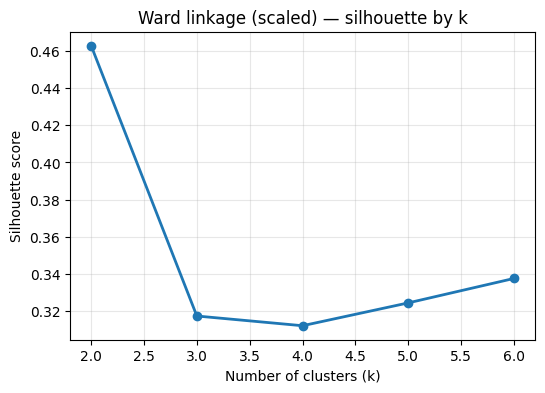


Best k by silhouette: 2 (score=0.4627)


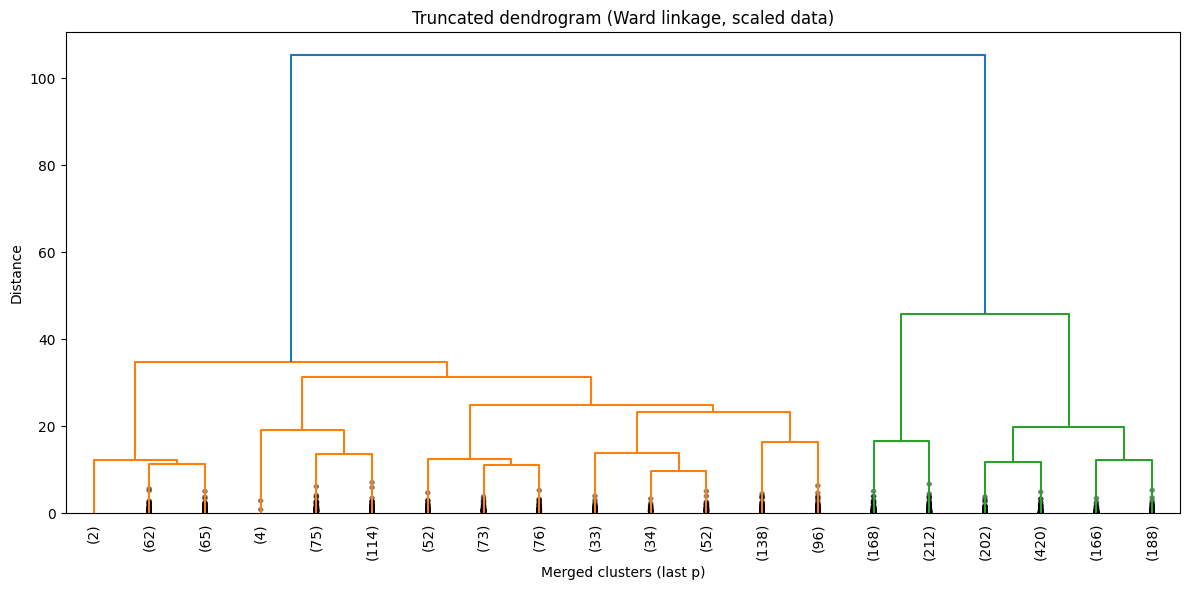

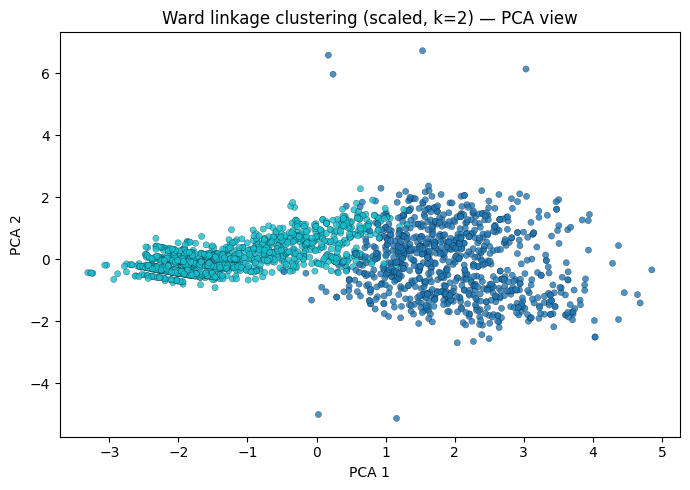

In [34]:
# improve Ward
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

# Prepare numeric features (use cleaned data if available) ---
data_src = df_clean if 'df_clean' in globals() else df
X_num = data_src.select_dtypes(include=['int64', 'float64']).copy()
X_num = X_num.drop(columns=[c for c in X_num.columns if c.lower() == 'cluster'], errors='ignore')

# (Optional) you can focus on a subset of informative features:
informative = ['Income', 'NumStorePurchases', 'NumWebPurchases', 'MntWines', 'MntMeatProducts']
X_num = X_num[[c for c in informative if c in X_num.columns]]

# Scale features (Ward uses Euclidean distances)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# Build Ward linkage on scaled data
Z_ward = linkage(X_scaled, method='ward')  # metric is Euclidean by definition

# Try different k and compute silhouette
k_values = range(2, 7)
sil_scores = {}

for k in k_values:
    labels_k = fcluster(Z_ward, t=k, criterion='maxclust')
    sil = silhouette_score(X_scaled, labels_k)
    sil_scores[k] = sil
    print(f"Silhouette (Ward, scaled) for k={k}: {sil:.4f}")

# Plot silhouette vs k
plt.figure(figsize=(6,4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), 'o-', lw=2)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Ward linkage (scaled) — silhouette by k")
plt.grid(True, alpha=0.3)
plt.show()

# Choose the best k (max silhouette) and visualize
best_k = max(sil_scores, key=sil_scores.get)
labels_best = fcluster(Z_ward, t=best_k, criterion='maxclust')

print(f"\nBest k by silhouette: {best_k} (score={sil_scores[best_k]:.4f})")

# Truncated dendrogram for a quick look
plt.figure(figsize=(12, 6))
dendrogram(
    Z_ward,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True,
)
plt.title("Truncated dendrogram (Ward linkage, scaled data)")
plt.xlabel("Merged clusters (last p)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# 2D PCA visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_best, cmap='tab10', s=20, alpha=0.8, edgecolors='k', linewidths=0.2)
plt.title(f"Ward linkage clustering (scaled, k={best_k}) — PCA view")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()



   std_no_log_no_pca | k=2 | silhouette=0.2827
   std_no_log_no_pca | k=3 | silhouette=0.1533
   std_no_log_no_pca | k=4 | silhouette=0.1656
   std_no_log_no_pca | k=5 | silhouette=0.1697
   std_no_log_no_pca | k=6 | silhouette=0.1718
      std_log_no_pca | k=2 | silhouette=0.2061
      std_log_no_pca | k=3 | silhouette=0.2009
      std_log_no_pca | k=4 | silhouette=0.1951
      std_log_no_pca | k=5 | silhouette=0.1942
      std_log_no_pca | k=6 | silhouette=0.2014
   robust_log_no_pca | k=2 | silhouette=0.2659
   robust_log_no_pca | k=3 | silhouette=0.1991
   robust_log_no_pca | k=4 | silhouette=0.1837
   robust_log_no_pca | k=5 | silhouette=0.1427
   robust_log_no_pca | k=6 | silhouette=0.1011
    robust_log_pca90 | k=2 | silhouette=0.2878
    robust_log_pca90 | k=3 | silhouette=0.2899
    robust_log_pca90 | k=4 | silhouette=0.2243
    robust_log_pca90 | k=5 | silhouette=0.1302
    robust_log_pca90 | k=6 | silhouette=0.1236
    robust_log_pca95 | k=2 | silhouette=0.2701
    robust_lo

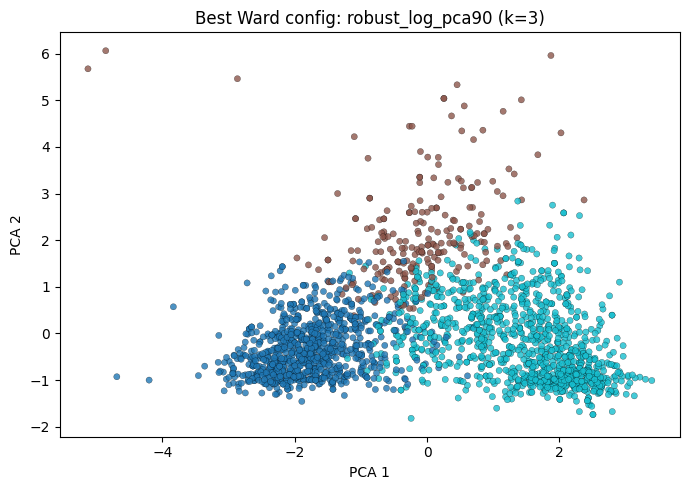

In [39]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster

# Base numeric data (use cleaned if exists)
data_src = df_clean if 'df_clean' in globals() else df
X = data_src.select_dtypes(include=['int64', 'float64']).copy()
X = X.drop(columns=[c for c in X.columns if c.lower() == 'cluster'], errors='ignore')

# Utility: drop highly correlated features to reduce redundancy
def drop_high_corr(df, thr=0.90):
    corr = df.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > thr)]
    return df.drop(columns=to_drop), to_drop

# Optional log1p transform for skewed spend/income columns
skew_candidates = [c for c in X.columns if c.lower().startswith('mnt') or 'income' in c.lower()]
def log_transform(df, cols):
    df2 = df.copy()
    for c in cols:
        if c in df2.columns:
            df2[c] = np.log1p(df2[c])
    return df2

# Try several preprocessing configs and k; pick best by silhouette
configs = [
    {"name": "std_no_log_no_pca",   "scaler": StandardScaler(), "log": False, "pca_var": None},
    {"name": "std_log_no_pca",      "scaler": StandardScaler(), "log": True,  "pca_var": None},
    {"name": "robust_log_no_pca",   "scaler": RobustScaler(),   "log": True,  "pca_var": None},
    {"name": "robust_log_pca90",    "scaler": RobustScaler(),   "log": True,  "pca_var": 0.90},
    {"name": "robust_log_pca95",    "scaler": RobustScaler(),   "log": True,  "pca_var": 0.95},
]

best = {"score": -1, "k": None, "name": None, "labels": None, "Z": None, "X_proc": None}

for cfg in configs:
    # log-transform
    Xc = log_transform(X, skew_candidates) if cfg["log"] else X.copy()
    # drop highly correlated features
    Xc, dropped = drop_high_corr(Xc, thr=0.90)
    # scale
    Xs = cfg["scaler"].fit_transform(Xc)
    # PCA
    if cfg["pca_var"] is not None:
        pca = PCA(n_components=cfg["pca_var"], svd_solver="full", random_state=42)
        Xproc = pca.fit_transform(Xs)
    else:
        Xproc = Xs

    # Ward linkage once per config
    Z = linkage(Xproc, method='ward')  # Euclidean implied

    for k in range(2, 7):
        labels = fcluster(Z, t=k, criterion='maxclust')
        sil = silhouette_score(Xproc, labels)
        print(f"{cfg['name']:>20} | k={k} | silhouette={sil:.4f}")
        if sil > best["score"]:
            best = {"score": sil, "k": k, "name": cfg["name"], "labels": labels, "Z": Z, "X_proc": Xproc}

print("\nBest config:", best["name"], "| best k:", best["k"], "| silhouette:", round(best["score"], 4))

Xp = best["X_proc"]
if Xp.shape[1] > 2:
    pca_plot = PCA(n_components=2, random_state=42)
    Xplot = pca_plot.fit_transform(Xp)
else:
    Xplot = Xp

plt.figure(figsize=(7,5))
plt.scatter(Xplot[:,0], Xplot[:,1], c=best["labels"], cmap="tab10", s=20, alpha=0.8, edgecolors='k', linewidths=0.2)
plt.title(f"Best Ward config: {best['name']} (k={best['k']})")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.tight_layout(); plt.show()


## Ward linkage + оптимізація

Ward linkage із різними підходами до препроцесингу: стандартне масштабування, лог-трансформація, RobustScaler, PCA.  
Найкращий результат показав підхід: лог-трансформація + RobustScaler + PCA (90% варіації).  

- Оптимальна кількість кластерів: **k=3**  
- Силует: ~0.29 — найкращий серед протестованих варіантів  
- Кластери стали більш компактними й розділеними, ніж у DBSCAN чи single linkage  

### Висновок:

Ward linkage після коректного препроцесингу дає найбільш стабільний і бізнес-інтерпретований результат.  
Три кластери можна трактувати як:  
- сегмент із нижчими доходами й малою активністю  
- середній сегмент  
- активні покупці з вищим доходом  

,Method,Preprocessing,k,Silhouette,Cluster sizes
0,KMeans,unscaled,2,0.6030,"{0: 1076, 1: 1156}"
1,KMeans,unscaled,3,0.5523,"{0: 786, 1: 731, 2: 715}"
2,Ward,unscaled,3,0.5353,"{1: 695, 2: 567, 3: 970}"
3,KMeans,unscaled,4,0.5342,"{0: 640, 1: 434, 2: 536, 3: 622}"
4,Ward,unscaled,2,0.5266,"{1: 695, 2: 1537}"
5,Ward,unscaled,4,0.4984,"{1: 695, 2: 567, 3: 398, 4: 572}"
6,KMeans,StandardScaler,2,0.4904,"{0: 2202, 1: 30}"
7,DBSCAN,"Std, eps=4.49, min_samples=10",auto,0.3349,"{-1: 135, 0: 2075, 1: 12, 2: 10}"
8,Ward,StandardScaler,2,0.2827,"{1: 573, 2: 1659}"
9,GMM,StandardScaler (BIC-selected),6,0.2050,"{0: 122, 1: 163, 2: 898, 3: 736, 4: 30, 5: 283}"


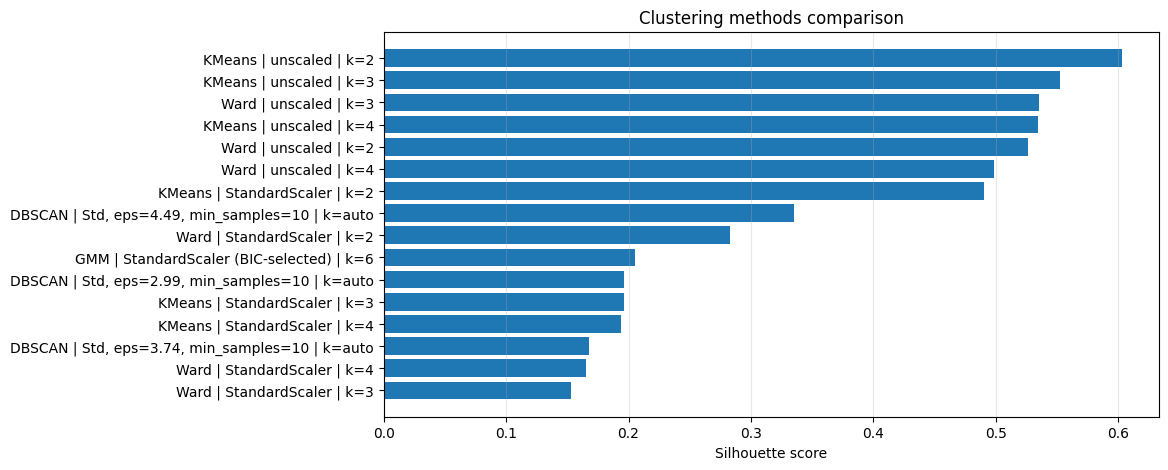

In [40]:
# Final comparison
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.neighbors import NearestNeighbors

# Data
data_src = df_clean if 'df_clean' in globals() else df
X_all = data_src.select_dtypes(include=['int64', 'float64']).copy()
X_all = X_all.drop(columns=[c for c in X_all.columns if c.lower() == 'cluster'], errors='ignore')

def cluster_sizes(labels):
    u, c = np.unique(labels, return_counts=True)
    return dict(zip(u.tolist(), c.tolist()))

rows = []

# KMeans
# Unscaled
X_raw = X_all.values
for k in [2,3,4]:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X_raw)
    sil = silhouette_score(X_raw, km.labels_)
    rows.append({
        "Method":"KMeans", "Preprocessing":"unscaled", "k":k,
        "Silhouette":sil, "Cluster sizes":cluster_sizes(km.labels_)
    })

# Scaled
Xs = StandardScaler().fit_transform(X_all)
for k in [2,3,4]:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(Xs)
    sil = silhouette_score(Xs, km.labels_)
    rows.append({
        "Method":"KMeans", "Preprocessing":"StandardScaler", "k":k,
        "Silhouette":sil, "Cluster sizes":cluster_sizes(km.labels_)
    })

# Ward linkage
# Unscaled
Z = linkage(X_raw, method='ward')
for k in [2,3,4]:
    lab = fcluster(Z, t=k, criterion='maxclust')
    sil = silhouette_score(X_raw, lab)
    rows.append({
        "Method":"Ward", "Preprocessing":"unscaled", "k":k,
        "Silhouette":sil, "Cluster sizes":cluster_sizes(lab)
    })

# Scaled (StandardScaler)
Zs = linkage(Xs, method='ward')
for k in [2,3,4]:
    lab = fcluster(Zs, t=k, criterion='maxclust')
    sil = silhouette_score(Xs, lab)
    rows.append({
        "Method":"Ward", "Preprocessing":"StandardScaler", "k":k,
        "Silhouette":sil, "Cluster sizes":cluster_sizes(lab)
    })

# DBSCAN - quick pass
# Heuristic eps via k-distance (k=min_samples)
min_samples = 10
nn = NearestNeighbors(n_neighbors=min_samples).fit(Xs)
dists, _ = nn.kneighbors(Xs)
d_curve = np.sort(dists[:, min_samples-1])
# crude elbow ~ 80th percentile as a fallback
eps_guess = np.percentile(d_curve, 80)

from sklearn.cluster import DBSCAN
for eps in [eps_guess*0.8, eps_guess, eps_guess*1.2]:
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(Xs)
    mask = db.labels_ != -1
    if mask.sum() > 0 and len(np.unique(db.labels_[mask])) > 1:
        sil = silhouette_score(Xs[mask], db.labels_[mask])
    else:
        sil = np.nan
    rows.append({
        "Method":"DBSCAN", "Preprocessing":f"Std, eps={eps:.2f}, min_samples={min_samples}",
        "k":"auto", "Silhouette":sil, "Cluster sizes":cluster_sizes(db.labels_)
    })

# GMM with BIC selection
best = {"bic": np.inf, "k": None, "model": None}
for k in range(2,7):
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42).fit(Xs)
    bic = gmm.bic(Xs)
    if bic < best["bic"]:
        best = {"bic": bic, "k": k, "model": gmm}
labels = best["model"].predict(Xs)
sil = silhouette_score(Xs, labels)
rows.append({
    "Method":"GMM", "Preprocessing":"StandardScaler (BIC-selected)",
    "k":best["k"], "Silhouette":sil, "Cluster sizes":cluster_sizes(labels)
})

# Summary table
summary = pd.DataFrame(rows).sort_values(by=["Silhouette"], ascending=False).reset_index(drop=True)
summary["Silhouette"] = summary["Silhouette"].round(4)
display(summary)

# Bar plot
plt.figure(figsize=(10,5))
plt.barh(
    [f"{r.Method} | {r.Preprocessing} | k={r.k}" for _, r in summary.iterrows()],
    summary["Silhouette"].values
)
plt.gca().invert_yaxis()
plt.xlabel("Silhouette score")
plt.title("Clustering methods comparison")
plt.grid(axis='x', alpha=0.3)
plt.show()


### Порівняння методів

- Найкращий результат дав KMeans без масштабування (k=2, силует ≈ 0.60) — чітке розділення на дві великі групи.  
- KMeans і Ward linkage при k=3–4 теж працюють непогано (силует ~0.49–0.55), але слабші за k=2.  
- DBSCAN і GMM показали низьку якість (силует <0.3), тому менш придатні для цього датасету.  

### Бізнес-інтерпретація

- Оптимально виділити 2–3 кластери:  
  - Масовий сегмент із середнім доходом і базовою активністю.  
  - Клієнти з високим доходом та активними покупками (VIP).  
  - За потреби — окремий сегмент із високим доходом, але низькою активністю (потенціал для стимулювання).  

### Використання для бізнесу

- Маркетинг: таргетовані кампанії для масового сегмента і VIP-клієнтів.  
- Продажі: акції для середнього сегмента для збільшення їх активності.  
- Лояльність: мотивація багатих, але пасивних клієнтів.  


